In [1]:
import os
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

#from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models, callbacks, mixed_precision
from sklearn.utils import class_weight


In [2]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Mixed precision → Faster on T4 / GPU
mixed_precision.set_global_policy('mixed_float16')


In [4]:
DATA_DIR = "C:\\Users\\Lenovo\\OneDrive\\Documents\\Dataset\\Plant_leave_diseases_dataset_with_augmentation"

assert os.path.exists(DATA_DIR), "Dataset path not found!"

print("Dataset Loaded:", DATA_DIR)
print("Total Classes:", len(os.listdir(DATA_DIR)))

Dataset Loaded: C:\Users\Lenovo\OneDrive\Documents\Dataset\Plant_leave_diseases_dataset_with_augmentation
Total Classes: 10


In [6]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS_PHASE1 = 15
EPOCHS_TOTAL = 50


In [7]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)


Found 15071 images belonging to 10 classes.
Found 3764 images belonging to 10 classes.


In [8]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights_dict = dict(enumerate(class_weights))


In [9]:
tf.keras.backend.clear_session()


In [11]:
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(train_gen.num_classes, activation='softmax', dtype='float32')
])


In [12]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

checkpoint = callbacks.ModelCheckpoint(
    "best_plant_model.h5",
    monitor="val_accuracy",
    save_best_only=True
)


In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print("Phase 1 Training...")

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Phase 1 Training...
Epoch 1/15
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6559 - loss: 1.6414

471/471 ━━━━━━━━━━━━━━━━━━━━ 1043s 2s/step - accuracy: 0.7342 - loss: 1.3754 - val_accuracy: 0.8781 - val_loss: 0.8882 - learning_rate: 0.0010
Epoch 2/15
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8224 - loss: 1.0489

471/471 ━━━━━━━━━━━━━━━━━━━━ 965s 2s/step - accuracy: 0.8339 - loss: 1.0067 - val_accuracy: 0.9121 - val_loss: 0.8196 - learning_rate: 0.0010
Epoch 3/15
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8662 - loss: 0.9247

471/471 ━━━━━━━━━━━━━━━━━━━━ 1023s 2s/step - accuracy: 0.8646 - loss: 0.9315 - val_accuracy: 0.9190 - val_loss: 0.7929 - learning_rate: 0.0010
Epoch 4/15
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8824 - loss: 0.8918

471/471 ━━━━━━━━━━━━━━━━━━━━ 997s 2s/step - accuracy: 0.8820 - loss: 0.8906 - val_accuracy: 0.9296 - val_loss: 0.7644 - learning_rate: 0.0010
Epoch 5/15
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8877 - loss: 0.8797

...

471/471 ━━━━━━━━━━━━━━━━━━━━ 1008s 2s/step - accuracy: 0.8981 - loss: 0.8488 - val_accuracy: 0.9408 - val_loss: 0.7384 - learning_rate: 0.0010
Epoch 7/15
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9059 - loss: 0.8366

471/471 ━━━━━━━━━━━━━━━━━━━━ 1029s 2s/step - accuracy: 0.9054 - loss: 0.8336 - val_accuracy: 0.9421 - val_loss: 0.7340 - learning_rate: 0.0010
Epoch 8/15
471/471 ━━━━━━━━━━━━━━━━━━━━ 917s 2s/step - accuracy: 0.9056 - loss: 0.8294 - val_accuracy: 0.9405 - val_loss: 0.7336 - learning_rate: 0.0010
Epoch 9/15
471/471 ━━━━━━━━━━━━━━━━━━━━ 860s 2s/step - accuracy: 0.9116 - loss: 0.8246 - val_accuracy: 0.9376 - val_loss: 0.7308 - learning_rate: 0.0010
Epoch 10/15
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9148 - loss: 0.8199

471/471 ━━━━━━━━━━━━━━━━━━━━ 858s 2s/step - accuracy: 0.9129 - loss: 0.8208 - val_accuracy: 0.9482 - val_loss: 0.7108 - learning_rate: 0.0010
Epoch 11/15
471/471 ━━━━━━━━━━━━━━━━━━━━ 875s 2s/step - accuracy: 0.9145 - loss: 0.8120 - val_accuracy: 0.9453 - val_loss: 0.7154 - learning_rate: 0.0010
Epoch 12/15
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9237 - loss: 0.7951

471/471 ━━━━━━━━━━━━━━━━━━━━ 869s 2s/step - accuracy: 0.9198 - loss: 0.8055 - val_accuracy: 0.9524 - val_loss: 0.7017 - learning_rate: 0.0010
Epoch 13/15
471/471 ━━━━━━━━━━━━━━━━━━━━ 847s 2s/step - accuracy: 0.9218 - loss: 0.8028 - val_accuracy: 0.9437 - val_loss: 0.7182 - learning_rate: 0.0010
Epoch 14/15
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9219 - loss: 0.7961

471/471 ━━━━━━━━━━━━━━━━━━━━ 848s 2s/step - accuracy: 0.9236 - loss: 0.7974 - val_accuracy: 0.9617 - val_loss: 0.7015 - learning_rate: 0.0010
Epoch 15/15
471/471 ━━━━━━━━━━━━━━━━━━━━ 848s 2s/step - accuracy: 0.9251 - loss: 0.7911 - val_accuracy: 0.9564 - val_loss: 0.6936 - learning_rate: 0.0010


In [ ]:
base_model.trainable = True

# Freeze BatchNorm layers
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print("Phase 2 Fine Tuning...")

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_TOTAL,
    initial_epoch=EPOCHS_PHASE1,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Phase 2 Fine Tuning...
Epoch 16/50
413/471 ━━━━━━━━━━━━━━━━━━━━ 1:44:12 108s/step - accuracy: 0.9446 - loss: 0.7407

In [15]:
model.save("final_plant_disease_model.h5")

with open("class_indices.pkl","wb") as f:
    pickle.dump(train_gen.class_indices, f)


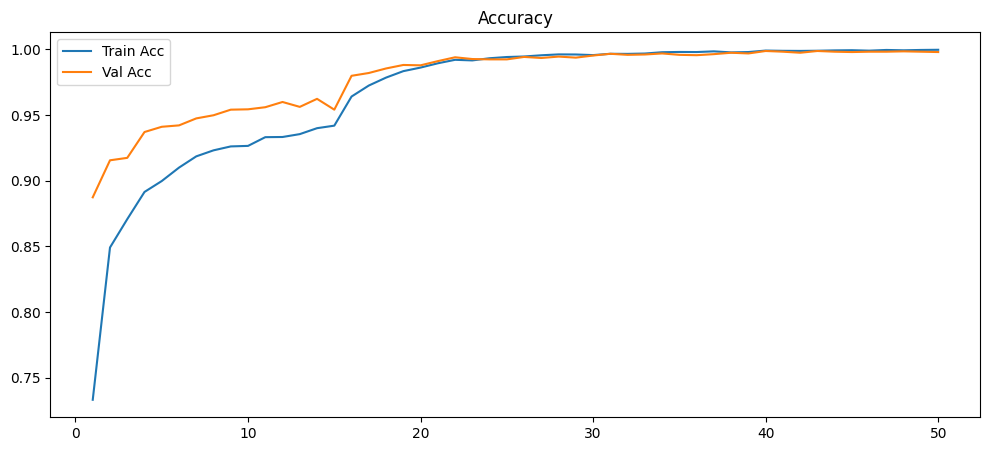

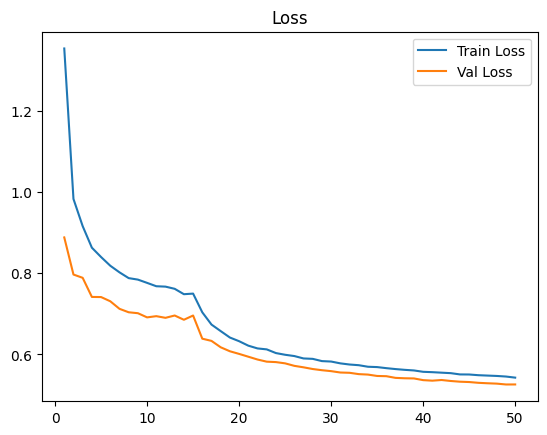

In [16]:
def plot_learning_curves(h1,h2):

    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    epochs = range(1,len(acc)+1)

    plt.figure(figsize=(12,5))
    plt.plot(epochs,acc,label="Train Acc")
    plt.plot(epochs,val_acc,label="Val Acc")
    plt.legend()
    plt.title("Accuracy")

    plt.figure()
    plt.plot(epochs,loss,label="Train Loss")
    plt.plot(epochs,val_loss,label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.show()

plot_learning_curves(history1,history2)


Generating predictions...
59/59 ━━━━━━━━━━━━━━━━━━━━ 70s 996ms/step


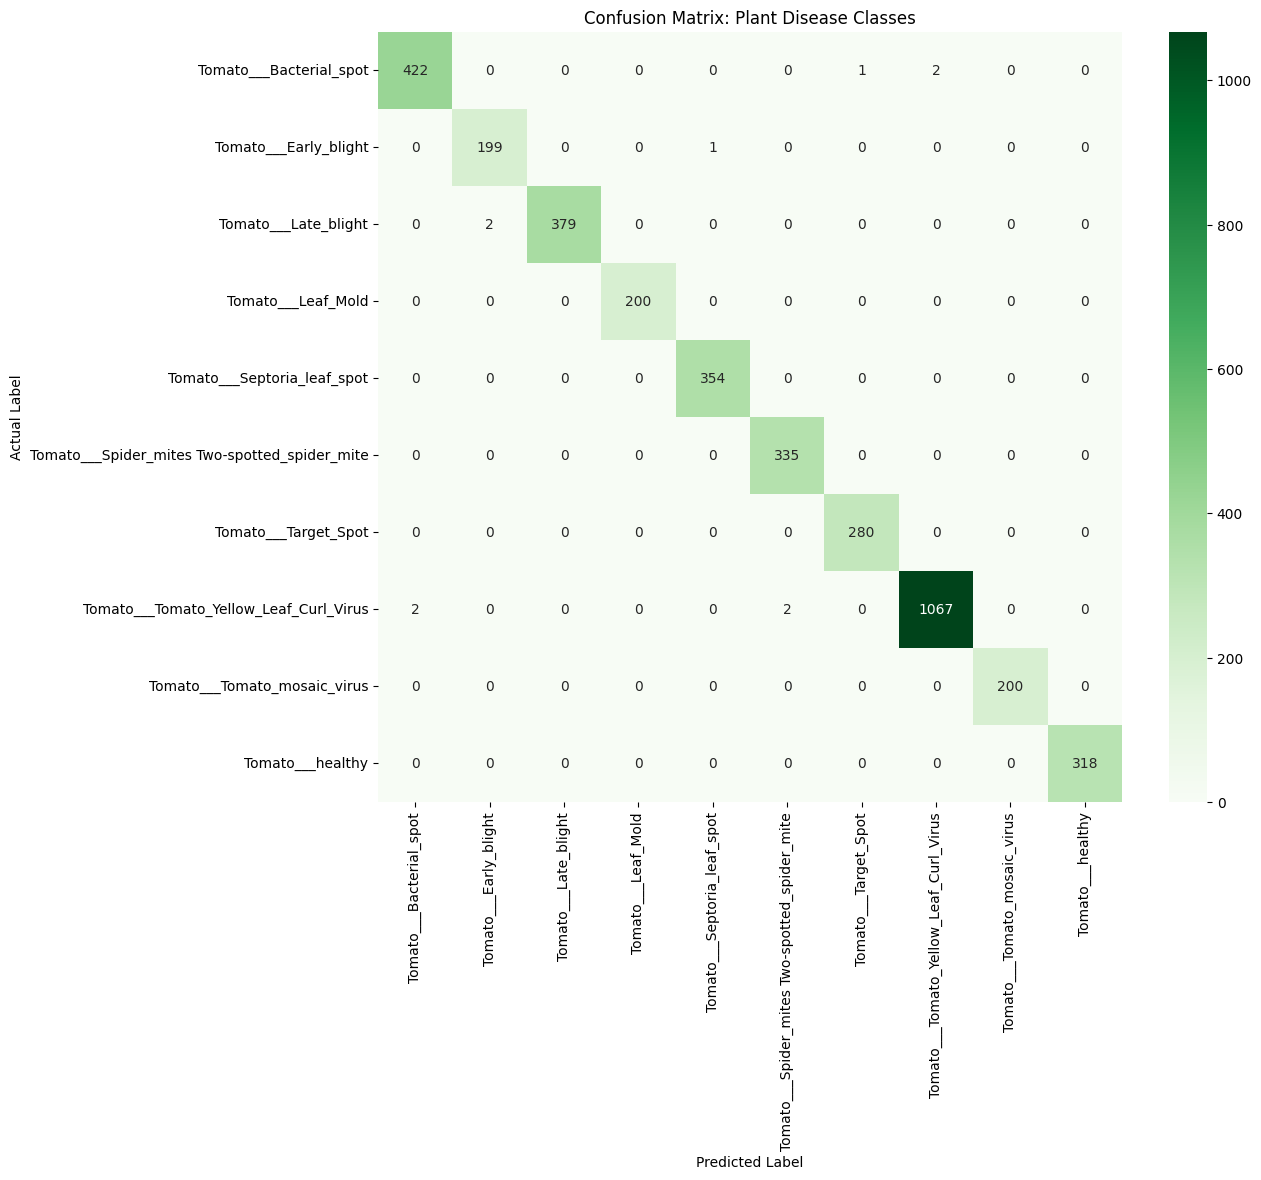


Classification Report:

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       1.00      0.99      0.99       425
                        Tomato___Early_blight       0.99      0.99      0.99       200
                         Tomato___Late_blight       1.00      0.99      1.00       381
                           Tomato___Leaf_Mold       1.00      1.00      1.00       200
                  Tomato___Septoria_leaf_spot       1.00      1.00      1.00       354
Tomato___Spider_mites Two-spotted_spider_mite       0.99      1.00      1.00       335
                         Tomato___Target_Spot       1.00      1.00      1.00       280
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      1.00      1.00      1071
                 Tomato___Tomato_mosaic_virus       1.00      1.00      1.00       200
                             Tomato___healthy       1.00      1.00      1.00       318

                

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Generate predictions for the validation set
print("Generating predictions...")
val_gen.reset() 
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

# 2. Get the class names
class_names = list(val_gen.class_indices.keys())

# 3. Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Plant Disease Classes')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=90)
plt.show()

# Print detailed metrics
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

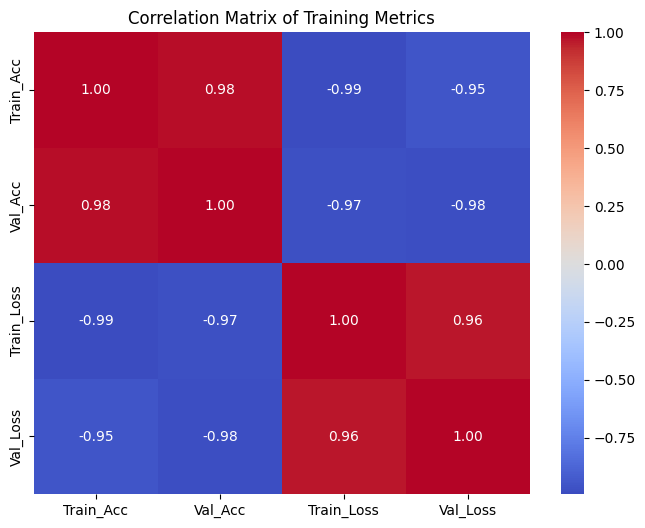

In [18]:
import pandas as pd

# Combine training histories (assuming history1 and history2 exist)
# If you have more phases, add them to the lists below
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

# Create a DataFrame
metrics_df = pd.DataFrame({
    'Train_Acc': acc,
    'Val_Acc': val_acc,
    'Train_Loss': loss,
    'Val_Loss': val_loss
})

# Calculate Correlation
corr = metrics_df.corr()

# Plotting the Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Training Metrics')
plt.show()